# Physiological Sepsis Phenotyping for Pitt Data 
## Step 0: Fetching waveform IDs of sepsis patient encounters (fin 2016-2022)




In [1]:
import pandas as pd
from datetime import datetime
import os
import numpy as np
# import wfdb
from scipy.io import loadmat
import glob
import h5py
import json
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [5]:
#!pip install wfdb


In [ ]:
df_sepsis = pd.read_csv('../Sepsis_PittsSuper_table_2_12_24.csv')
df_sepsis

In [7]:
df_sepsis.columns, df_sepsis.shape, len(df_sepsis.fin.unique())

(Index(['Unnamed: 0', 'result_val_SpO2', 'result_val_PAO2',
        'result_val_Glasgow_Coma_Score', 'result_val_Mean_blood_pressure',
        'result_val_norepinephrine', 'result_val_DOBUTamine',
        'result_val_DOPamine', 'result_val_EPINEPHrine', 'result_val_Bilirubin',
        'result_val_Creatinine', 'result_val_Platelets', 'result_val_FIO2',
        'FIN', 'val_cardio', 'val_cardio_mod', 'val_neuro', 'val_hep',
        'val_renal', 'val_coag', 'PF', 'val_resp', 'SF', 'val_resp_sa', 'sofa',
        'delta_24hr_sofa', 'hourly', 't_sepsis', 't_sepsis_diff', 'fin'],
       dtype='object'),
 (327986, 30),
 4806)

In [ ]:
'''
INDEX SEPSIS-3 TIME:
First sorting sepsis 3 in asending order then apply drop duplicates by keeping first

df_sepsis should carry admission year information and patient ID info as well, but it doesn't.
'''

### 
df_sepsis['fin'] = df_sepsis['fin'].astype(int)
df_sepsis['t_sepsis'] = pd.to_datetime(df_sepsis['t_sepsis'])
df_sepsis['year_sepsis'] = df_sepsis['t_sepsis'].dt.year
df_index_sepsis_yrs = df_sepsis.sort_values(by=['fin','t_sepsis'])

df_index_sepsis_yrs.drop_duplicates(subset=['fin'], keep='first', inplace=True)
df_index_sepsis_yrs.reset_index(inplace=True, drop=True)
df_index_sepsis_yrs = df_index_sepsis_yrs[['fin','year_sepsis','t_sepsis', 'result_val_SpO2', 'result_val_PAO2',
        'result_val_Glasgow_Coma_Score', 'result_val_Mean_blood_pressure', 'PF', 'SF',
        'result_val_norepinephrine', 'result_val_DOBUTamine',
        'result_val_DOPamine', 'result_val_EPINEPHrine', 'result_val_Bilirubin',
        'result_val_Creatinine', 'result_val_Platelets', 'result_val_FIO2',
        'val_cardio', 'val_cardio_mod', 'val_neuro', 'val_hep',
        'val_renal', 'val_coag', 'val_resp', 'sofa', 'hourly']]
df_index_sepsis_yrs

In [9]:
df_index_sepsis_yrs.dtypes

fin                                        int64
year_sepsis                                int32
t_sepsis                          datetime64[ns]
result_val_SpO2                          float64
result_val_PAO2                          float64
result_val_Glasgow_Coma_Score            float64
result_val_Mean_blood_pressure           float64
PF                                       float64
SF                                       float64
result_val_norepinephrine                float64
result_val_DOBUTamine                    float64
result_val_DOPamine                      float64
result_val_EPINEPHrine                   float64
result_val_Bilirubin                     float64
result_val_Creatinine                    float64
result_val_Platelets                     float64
result_val_FIO2                          float64
val_cardio                               float64
val_cardio_mod                           float64
val_neuro                                float64
val_hep             

In [10]:
len(df_index_sepsis_yrs.fin.unique())

4806

In [11]:
fin_id_sepsis = df_index_sepsis_yrs['fin'].values
len(fin_id_sepsis)

4806

In [12]:
df_sepsis['t_sepsis'].dt.year.value_counts(), df_index_sepsis_yrs.year_sepsis.value_counts()

(t_sepsis
 2019    94706
 2020    90595
 2018    54322
 2021    52536
 2017    23153
 2022     9090
 2016     3584
 Name: count, dtype: int64,
 year_sepsis
 2020    1370
 2019    1347
 2018     819
 2021     725
 2017     355
 2022     130
 2016      60
 Name: count, dtype: int64)

In [13]:
df_index_sepsis_yrs.year_sepsis.value_counts().reset_index().sort_values(by='year_sepsis')

,year_sepsis,count
6,2016,60
4,2017,355
2,2018,819
1,2019,1347
0,2020,1370
3,2021,725
5,2022,130


In [15]:
# os.listdir('../../../../../ix1/mladi/work/')

In [16]:
signal_path = '../../../../../ix1/mladi/work/extracted/'

df_wave = pd.DataFrame(os.listdir(signal_path), columns =['waveID'])
df_wave['parts'] = [x.count('_') for x in df_wave['waveID']]
df_wave = df_wave[df_wave['parts']==2]
date_updated = [x.split('_')[0] for x in df_wave['waveID']]
studyID = [x.split('_')[1] for x in df_wave['waveID']]
finID = [x.split('_')[2].split('.')[0] for x in df_wave['waveID']]
df_wave['fin'] = pd.to_numeric(finID)
df_wave['studyID'] = np.asarray(studyID)
df_wave['date_updated'] = pd.to_datetime(date_updated)

In [ ]:
df_wave

## Filter some duplicated fin by keeping one only with their latest updated date

In [13]:
# ### Ignore some fin having double patients data issues

# df_ignore = pd.read_csv('Pats_pitts_ignore.txt')
# fin_ignore = [x.split('/')[0] for x in df_ignore['fin/studyid']]
# studyid_ignore = [x.split('/')[1] for x in df_ignore['fin/studyid']]
# df_ignore['fin_ignore'] = np.asarray(fin_ignore, dtype=int)
# df_ignore['studyid_ignore'] = studyid_ignore.copy()
# df_ignore
# df_index_sepsis_yrs1 = df_index_sepsis_yrs[~df_index_sepsis_yrs['fin'].isin(df_ignore.fin_ignore)]
# df_index_sepsis_yrs1

In [ ]:
df_wave1 = df_wave.sort_values(by=['fin','date_updated'], ascending=False, ignore_index=True)
df_wave1.drop_duplicates(subset=['fin'], ignore_index=True, inplace=True)
df_wave1

In [15]:
len(df_wave.fin.unique()), len(df_wave.studyID.unique()), len(df_wave1.fin.unique()), len(df_wave1.studyID.unique())

(20168, 18306, 20168, 18277)

In [16]:
len(df_index_sepsis_yrs.fin.unique())

4806

In [ ]:
'''
Get Waveform matched sepsis patients: MERGING df_index_sepsis_yrs and df_wave1

'''

df_index_sepsis_yrs2 = df_index_sepsis_yrs.merge(df_wave1, on=['fin'], how='left')
df_index_sepsis_yrs3 = df_index_sepsis_yrs2[~df_index_sepsis_yrs2.parts.isnull()]
df_index_sepsis_yrs3.reset_index(drop=True, inplace=True)
df_index_sepsis_yrs3

In [18]:
# df_index_sepsis_yrs3.to_csv('Data_folder/df_step0_WaveMatchedSepsisPats_table.csv')







In [19]:
len(df_index_sepsis_yrs3.fin.unique())

4038

In [22]:
path_pat1 = '../../../../../ix1/mladi/work/extracted/20200307_1845732_1999905.h5'
hf1 = h5py.File(path_pat1, 'r')
# t_origin = pd.to_datetime(json.loads(hf1.attrs['.meta'])['time_origin']).tz_localize(None)
# t_origin

In [23]:
hf1.keys()

<KeysViewHDF5 ['data', 'dwc', 'ehr']>

In [24]:
hf1['data']['waveforms'].keys()

<KeysViewHDF5 ['ART', 'II', 'III', 'Pleth', 'Resp', 'UAP', 'V', 'aVR']>

In [25]:
plt.plot(list(zip(*hf1['data']['waveforms']['ABP'][:][2000:3000]))[1])
plt.ylabel('ABP (mmHg)')

KeyError: "Unable to synchronously open object (object 'ABP' doesn't exist)"

Text(0, 0.5, 'ART (mmHg)')

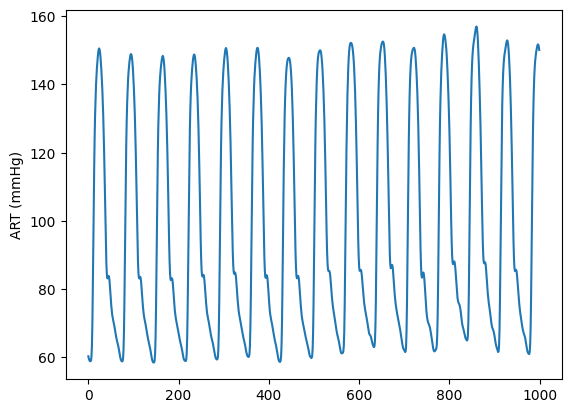

In [26]:
plt.plot(list(zip(*hf1['data']['waveforms']['ART'][:][2000:3000]))[1])
plt.ylabel('ART (mmHg)')

Text(0, 0.5, 'PPG')

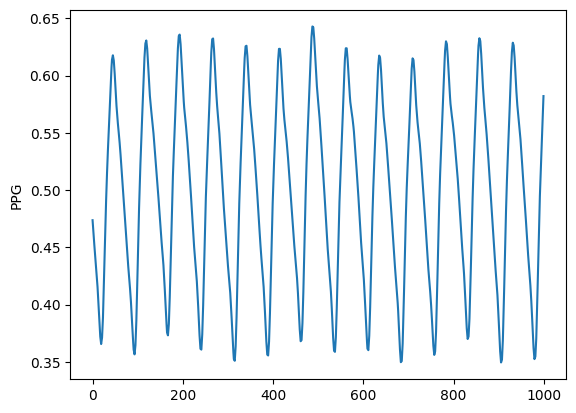

In [27]:
plt.plot(list(zip(*hf1['data']['waveforms']['Pleth'][:][12000:13000]))[1])
plt.ylabel('PPG')

Text(0, 0.5, 'ECG (mv)')

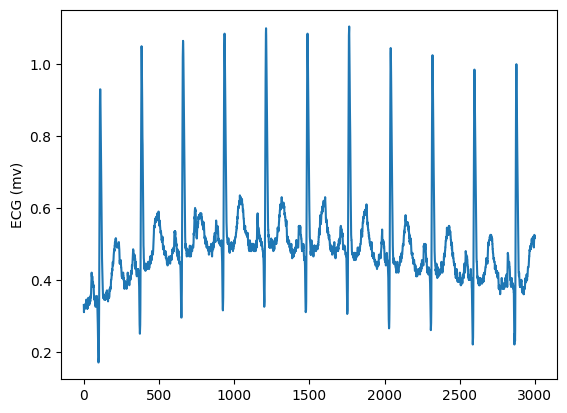

In [28]:
plt.plot(list(zip(*hf1['data']['waveforms']['II'][:][2000:5000]))[1])
plt.ylabel('ECG (mv)')

Text(0, 0.5, 'Resp')

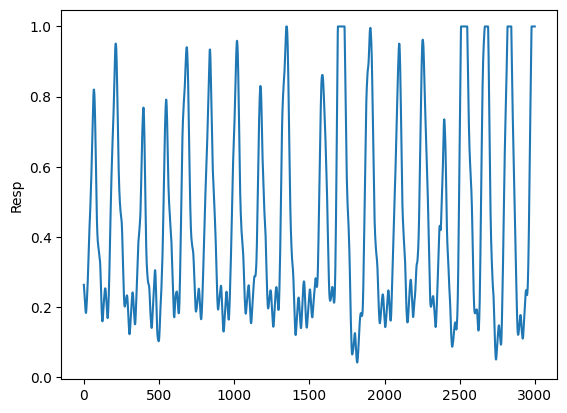

In [29]:
plt.plot(list(zip(*hf1['data']['waveforms']['Resp'][:][5000:8000]))[1])
plt.ylabel('Resp')

In [30]:
h5_ecg = hf1['data']['waveforms']['II'][:]

In [31]:
h5_ecg

array([(442778.06399989, 0.275), (442778.06599998, 0.27 ),
       (442778.06800008, 0.27 ), ..., (665321.82123899, 0.48 ),
       (665321.82323909, 0.48 ), (665321.82523918, 0.5  )],
      dtype=[('time', '<f8'), ('value', '<f4')])

In [32]:
list(zip(*h5_ecg[:10]))[0]

(442778.0639998913,
 442778.06599998474,
 442778.0680000782,
 442778.07000017166,
 442778.0720002651,
 442778.0740003586,
 442778.07600045204,
 442778.0780005455,
 442778.08000063896,
 442778.0820007324)

In [33]:
t_ecg, amp_ecg=[list(zip(*h5_ecg[:10000]))[0], list(zip(*h5_ecg[:10000]))[1]]

Text(0.5, 0, 'Index')

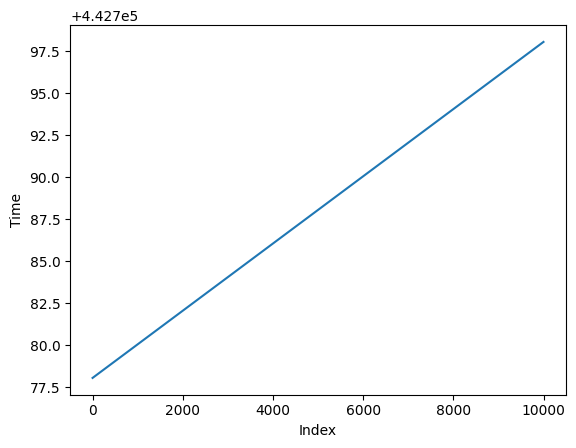

In [34]:
plt.plot(t_ecg)
plt.ylabel('Time')
plt.xlabel('Index')

Text(0.5, 0, 'Index')

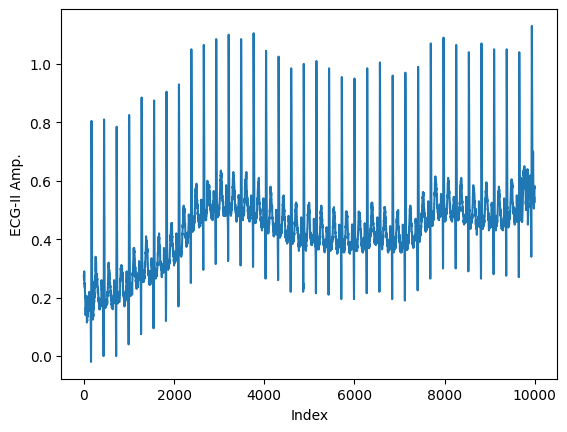

In [35]:
plt.plot(amp_ecg)
plt.ylabel('ECG-II Amp.')
plt.xlabel('Index')
# plt.xlim([25120, 25135])

Text(0.5, 0, 'Time (s)')

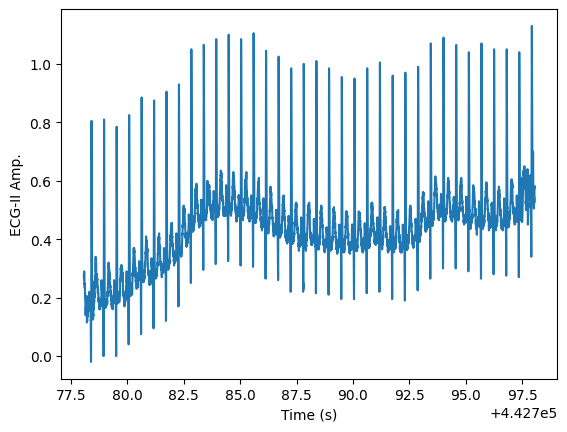

In [36]:
plt.plot(t_ecg, amp_ecg)
plt.ylabel('ECG-II Amp.')
plt.xlabel('Time (s)')

In [37]:
df_t_ecg = pd.DataFrame(t_ecg, columns=['t'])

In [38]:
df_t_ecg['t'].diff().value_counts()

t
0.002000    9996
0.001761       2
0.001761       1
Name: count, dtype: int64

In [39]:
df_t_ecg['t'].diff().describe()

count    9999.000000
mean        0.002000
std         0.000004
min         0.001761
25%         0.002000
50%         0.002000
75%         0.002000
max         0.002000
Name: t, dtype: float64